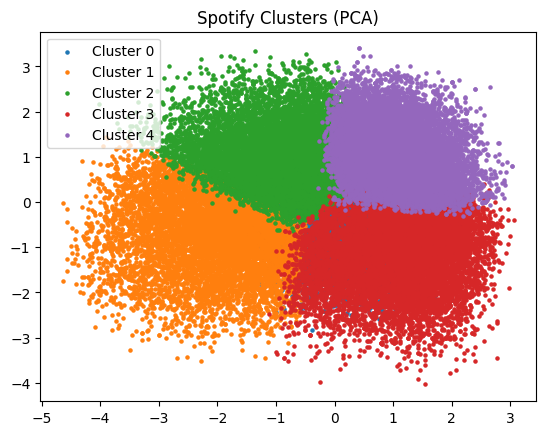

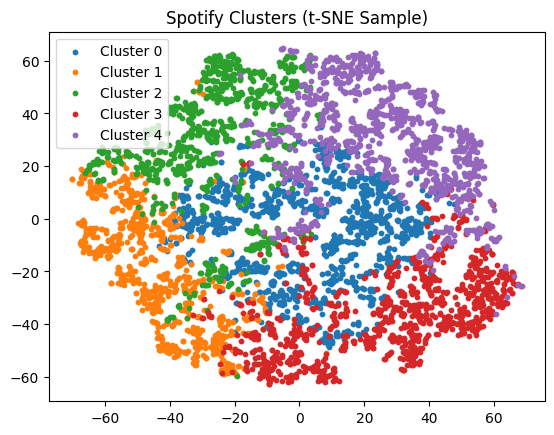

         danceability    energy       tempo   loudness   valence
cluster                                                         
0            0.540868  0.780223  105.662198  -5.354402  0.343826
1            0.470843  0.381355  116.599285 -10.956869  0.245750
2            0.690010  0.521238  114.324923  -9.800218  0.580910
3            0.453840  0.823365  160.028215  -5.046672  0.444464
4            0.673108  0.811302  120.435526  -5.182833  0.719111


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load first 50k rows
df = pd.read_csv("SpotifyFeatures.csv").iloc[:50000]

# 1. Remove duplicate rows
df = df.drop_duplicates()


# 2. Keep only required columns
features = ['danceability','energy','tempo','loudness','valence']
df = df[features]


# 3. Outlier Removal using IQR
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]


# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df) # X_scaled must be computed from the cleaned df


# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Conducting Principal Component Analysis
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure()
for c in sorted(df['cluster'].unique()):
    plt.scatter(
        pca_result[df['cluster']==c,0],
        pca_result[df['cluster']==c,1],
        label=f'Cluster {c}',
        s=5
    )
plt.title("Spotify Clusters (PCA)")
plt.legend()
plt.show()

# t-SNE on a small sample size
sample_df = df.sample(5000, random_state=42)
sample_features = sample_df[['danceability','energy','tempo','loudness','valence']]

sample_scaled = scaler.transform(sample_features)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(sample_scaled)

plt.figure()
for c in sorted(sample_df['cluster'].unique()):
    plt.scatter(
        tsne_result[sample_df['cluster']==c,0],
        tsne_result[sample_df['cluster']==c,1],
        label=f'Cluster {c}',
        s=10
    )
plt.title("Spotify Clusters (t-SNE Sample)")
plt.legend()
plt.show()


print(df.groupby('cluster')[['danceability','energy','tempo','loudness','valence']].mean())

The t-SNE plot further highlights distinct groupings. Overall, the clusters represent different types of music such as high-energy fast-tempo tracks, calm or mellow songs, upbeat music, and moderately energetic songs, demonstrating that these audio features capture patterns in song style and mood.


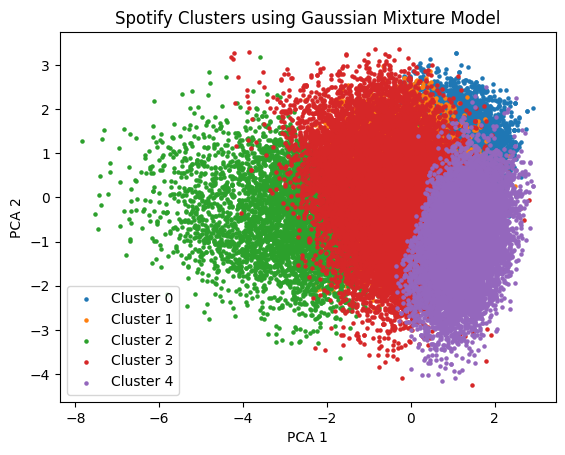

         danceability    energy       tempo   loudness   valence
cluster                                                         
0            0.666352  0.795511  109.155493  -5.536670  0.742651
1            0.581990  0.649478   99.369179  -6.591615  0.363943
2            0.395662  0.233112  111.553175 -14.857984  0.180993
3            0.566011  0.558043  135.919357  -9.728014  0.474182
4            0.519387  0.887676  148.092712  -4.154616  0.475143


In [10]:
#Using the Gaussian Mixture Model
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

gmm = GaussianMixture(n_components=5, random_state=42)
df['cluster'] = gmm.fit_predict(X_scaled)

# PCA visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure()

for c in sorted(df['cluster'].unique()):
    plt.scatter(
        pca_result[df['cluster']==c,0],
        pca_result[df['cluster']==c,1],
        label=f'Cluster {c}',
        s=5
    )

plt.title("Spotify Clusters using Gaussian Mixture Model")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

print(df.groupby('cluster')[features].mean())

Using the Gaussian Mixture Model will allow for an overlap of the clusters allowing for more accurate clusters in the realm of songs, which may be the case for songs that are of multi-genre.

In [19]:
# Evalation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("\nKMEANS RESULTS")

print("Silhouette Score:",
      silhouette_score(X_scaled, kmeans_labels))

print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled, kmeans_labels))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_scaled, kmeans_labels))


KMEANS RESULTS
Silhouette Score: 0.1946222907520573
Davies-Bouldin Index: 1.4453171509921485
Calinski-Harabasz Score: 13061.913231158498


In [20]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


gmm = GaussianMixture(n_components=5, random_state=42)

gmm_labels = gmm.fit_predict(X_scaled)

df['gmm_cluster'] = gmm_labels

print("\nGMM RESULTS")

print("Silhouette Score:",
      silhouette_score(X_scaled, gmm_labels))

print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled, gmm_labels))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_scaled, gmm_labels))




GMM RESULTS
Silhouette Score: 0.13652849939868414
Davies-Bouldin Index: 1.719492745818807
Calinski-Harabasz Score: 9391.282229170096


Silhouette Score (0.19 vs 0.136):
Measures how similar a point is to its own cluster compared to other clusters.  A higher value is better because it means clusters are well separated.

Davies–Bouldin Index (1.44 vs 1.71):
Measures how similar clusters are to each other. It compares within-cluster spread vs distance between clusters. A lower value is better because it means clusters are compact and far apart.

Calinski–Harabasz Score (13061 vs 9391):
Measures the ratio of between-cluster variance to within-cluster variance. A higher value is better because it indicates clusters are dense and well separated.

From comparing these metrics with both the models, the K-Means model seems to have performed better in all metrics provided.

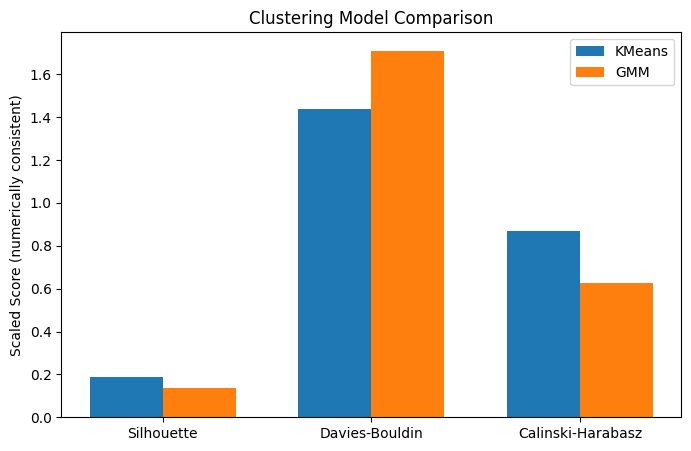

In [26]:
import matplotlib.pyplot as plt
import numpy as np

kmeans_scores = [0.19, 1.44, 13061]
gmm_scores = [0.136, 1.71, 9391]

metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']

# copy so we don't modify originals
kmeans_plot = kmeans_scores.copy()
gmm_plot = gmm_scores.copy()

# scale only the large metric so it fits on the chart
scale_factor = 15000
kmeans_plot[2] = kmeans_plot[2] / scale_factor
gmm_plot[2] = gmm_plot[2] / scale_factor

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, kmeans_plot, width, label='KMeans')
plt.bar(x + width/2, gmm_plot, width, label='GMM')

plt.xticks(x, metrics)
plt.ylabel("Scaled Score (numerically consistent)")
plt.title("Clustering Model Comparison")
plt.legend()

plt.show()